# 01 Dataset Exploration

This notebook performs the first safe inspection of the local PhiUSIIL dataset. It does not open or visit any URL. URLs are treated only as text, and any URL values shown are defanged first.

## 1. Imports

We import pandas for data analysis, matplotlib for charts, and pathlib for project paths.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\singh\\AppData\\Local\\matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


## 2. Load the Local Raw Dataset

The dataset is read from the local CSV file only. No network request is made.

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_FILE = PROJECT_ROOT / "data" / "raw" / "phiusil_raw.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RAW_DATA_FILE)

## 3. Dataset Shape

The shape tells us how many records and columns are available before any cleaning or feature selection.

In [3]:
df.shape

(235795, 55)

## 4. Safe Preview Columns

Raw phishing URLs should not be displayed directly. This preview creates a defanged copy of the URL text before showing examples.

In [4]:
def defang_url(value):
    """Return a safer display version of URL text."""
    return str(value).replace("http://", "hxxp://").replace("https://", "hxxps://").replace(".", "[.]")


safe_preview = df[["URL", "Domain", "TLD", "label"]].head().copy()
safe_preview["URL_defanged"] = safe_preview["URL"].map(defang_url)
safe_preview[["URL_defanged", "Domain", "TLD", "label"]]

,URL_defanged,Domain,TLD,label
0,hxxps://www[.]southbankmosaics[.]com,www.southbankmosaics.com,com,1
1,hxxps://www[.]uni-mainz[.]de,www.uni-mainz.de,de,1
2,hxxps://www[.]voicefmradio[.]co[.]uk,www.voicefmradio.co.uk,uk,1
3,hxxps://www[.]sfnmjournal[.]com,www.sfnmjournal.com,com,1
4,hxxps://www[.]rewildingargentina[.]org,www.rewildingargentina.org,org,1


## 5. Column Names

Listing column names helps us understand which fields are URL-based and which may depend on webpage content.

In [5]:
list(df.columns)

['URL',
 'URLLength',
 'Domain',
 'DomainLength',
 'IsDomainIP',
 'TLD',
 'URLSimilarityIndex',
 'CharContinuationRate',
 'TLDLegitimateProb',
 'URLCharProb',
 'TLDLength',
 'NoOfSubDomain',
 'HasObfuscation',
 'NoOfObfuscatedChar',
 'ObfuscationRatio',
 'NoOfLettersInURL',
 'LetterRatioInURL',
 'NoOfDegitsInURL',
 'DegitRatioInURL',
 'NoOfEqualsInURL',
 'NoOfQMarkInURL',
 'NoOfAmpersandInURL',
 'NoOfOtherSpecialCharsInURL',
 'SpacialCharRatioInURL',
 'IsHTTPS',
 'LineOfCode',
 'LargestLineLength',
 'HasTitle',
 'Title',
 'DomainTitleMatchScore',
 'URLTitleMatchScore',
 'HasFavicon',
 'Robots',
 'IsResponsive',
 'NoOfURLRedirect',
 'NoOfSelfRedirect',
 'HasDescription',
 'NoOfPopup',
 'NoOfiFrame',
 'HasExternalFormSubmit',
 'HasSocialNet',
 'HasSubmitButton',
 'HasHiddenFields',
 'HasPasswordField',
 'Bank',
 'Pay',
 'Crypto',
 'HasCopyrightInfo',
 'NoOfImage',
 'NoOfCSS',
 'NoOfJS',
 'NoOfSelfRef',
 'NoOfEmptyRef',
 'NoOfExternalRef',
 'label']

## 6. Data Types

Data types show whether columns are numeric, text, or another kind of value.

In [6]:
df.dtypes

URL                               str
URLLength                       int64
Domain                            str
DomainLength                    int64
IsDomainIP                      int64
TLD                               str
URLSimilarityIndex            float64
CharContinuationRate          float64
TLDLegitimateProb             float64
URLCharProb                   float64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS                         int64
LineOfCode                      int64
LargestLineL

## 7. Missing-Value Summary

Missing values can affect model training, so we check every column before modeling.

In [7]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]

Series([], dtype: int64)

If the result above is empty, pandas found no missing values in any column.

## 8. Target-Class Counts

The target column is `label`, where `0` means phishing and `1` means legitimate.

In [8]:
class_counts = df["label"].value_counts().sort_index()
class_counts

label
0    100945
1    134850
Name: count, dtype: int64

## 9. Target-Class Percentages

Percentages make the class balance easier to interpret.

In [9]:
class_percentages = (class_counts / len(df) * 100).round(2)
class_percentages

label
0    42.81
1    57.19
Name: count, dtype: float64

## 10. Bar Chart of Phishing Versus Legitimate Records

This chart visualizes the target-class distribution and is saved under `reports/figures/`.

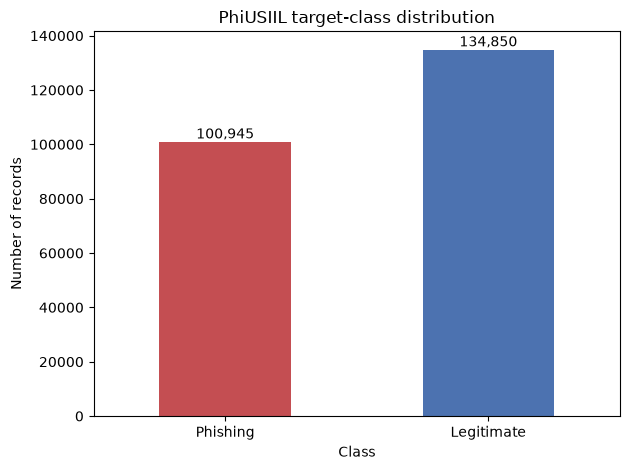

WindowsPath('D:/Projects/phishing-url-detection/reports/figures/class_distribution.png')

In [10]:
label_names = {0: "Phishing", 1: "Legitimate"}
plot_counts = class_counts.rename(index=label_names)

ax = plot_counts.plot(kind="bar", color=["#c44e52", "#4c72b0"], rot=0)
ax.set_title("PhiUSIIL target-class distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of records")

for position, value in enumerate(plot_counts):
    ax.text(position, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
figure_path = FIGURES_DIR / "class_distribution.png"
plt.savefig(figure_path, dpi=150)
plt.show()

figure_path